# Time-Series Cross-Validation 

5-fold expanding-window:

| Fold | Train ≤ | Val | Test (held out) |
|------|---------|-----|-----------------|
| 1 | 2018 | 2019 | 2024+2025 |
| 2 | 2019 | 2020 | 2024+2025 |
| 3 | 2020 | 2021 | 2024+2025 |
| 4 | 2021 | 2022 | 2024+2025 |
| 5 | 2022 | 2023 | 2024+2025 |

# Pre processing

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau

SEED = 42
DATA_PATH = Path("Merged_Dataset_yoy.csv")
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
DEFAULT_LOOKBACK_DAYS = 365

MAX_EPOCHS = 200
PATIENCE = MAX_EPOCHS
TEST_YEAR_CUTOFF = 2023
N_SPLITS = 5
N_RUNS = 20
SYMLOG_CAP = float(np.log1p(3.0))

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, torch.get_num_threads() // 2))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data Processing

In [ ]:
def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = 365):
    try:
        df = pd.read_csv(data_path)
    except FileNotFoundError:
        df = pd.read_csv("Merged_Dataset_yoy.csv")

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()
    prior_static_cols = [
        "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
        "Leverage", "Cash_Ratio", "Size_SL",
        "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL",
    ]
    current_year_cols = [
        "Total_Assets", "Total_Debt", "Cash",
        "Net_Sales", "Operating_Expenses", "FCF_Per_Share",
    ]
    static_cols = ["MC_MIB", "MC_MID", "MC_SMALL", "Sector"]
    exclude_cols = ({"Date", "Company", "year", "has_targets"}
                    | set(PREDICTION_TARGETS) | set(prior_static_cols)
                    | set(current_year_cols) | set(static_cols))
    feature_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            year_end_date = year_end_row["Date"]

            prior_year_records = year_end_records[
                (year_end_records["Company"] == company) & (year_end_records["year"] == year - 1)
            ]
            if prior_year_records.empty:
                continue

            prior_row = prior_year_records.iloc[0]
            window_start = year_end_date - pd.Timedelta(days=lookback_days)
            window = company_data[(company_data["Date"] > window_start) & (company_data["Date"] <= year_end_date)].copy()

            if len(window) < 200:
                continue

            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            static_cols = ["MC_MIB", "MC_MID", "MC_SMALL",
                           "Prior_EBITDA_SL", "Prior_NI_SL", "Prior_ROA",
                           "Leverage", "Cash_Ratio", "Size_SL",
                           "Prior_Net_Sales_SL", "Prior_OpEx_SL", "Prior_FCF_Per_Share_SL"]
            static_data = window[static_cols].iloc[-1].to_numpy(dtype=np.float32)
            sector_str = str(window["Sector"].iloc[-1])

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": window[feature_cols].to_numpy(dtype=np.float32),
                "static_data": static_data,
                "sector": sector_str,
                **{f"current_{t.lower()}": year_end_row[t] for t in PREDICTION_TARGETS},
                **{f"prior_{t.lower()}": prior_row[t] for t in PREDICTION_TARGETS},
            })

    data_records = []
    for seq in sequences:
        for target_name in PREDICTION_TARGETS:
            current_val = seq[f"current_{target_name.lower()}"]
            prior_val = seq[f"prior_{target_name.lower()}"]
            if pd.isna(current_val) or pd.isna(prior_val):
                continue

            label_value = (current_val - prior_val) / (np.abs(prior_val) + 1e-8)

            data_records.append({
                "company": seq["company"], "year": seq["year"], "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label_value,
                "window_data": seq["window_data"],
                "static_data": seq["static_data"],
                "sector": seq["sector"],
            })

    return pd.DataFrame(data_records), feature_cols

data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH, lookback_days=DEFAULT_LOOKBACK_DAYS)

def temporal_kfold_split(df: pd.DataFrame, n_splits: int = N_SPLITS, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    if df.empty:
        raise ValueError("The dataset is empty. Check if DEFAULT_LOOKBACK_DAYS is too small.")

    available_years = sorted(int(y) for y in df["year"].unique())
    pre_test_years = [y for y in available_years if y <= test_year_cutoff]
    print(f"Available years in dataset: {available_years}")

    if len(pre_test_years) < n_splits + 1:
        raise ValueError(f"Not enough pre-test years ({len(pre_test_years)}) for {n_splits} folds (need >= {n_splits+1}).")

    val_years = pre_test_years[-n_splits:]
    test_set = df[df["year"] > test_year_cutoff].copy()
    print(f"Test: > {test_year_cutoff} ({len(test_set)} samples)")
    print(f"Temporal k-fold ({n_splits} folds, expanding window). Val years: {val_years}")

    folds = []
    for fold_idx, vy in enumerate(val_years, start=1):
        train_set = df[df["year"] < vy].copy()
        val_set = df[df["year"] == vy].copy()
        if train_set.empty or val_set.empty:
            print(f"WARNING: fold {fold_idx} (val {vy}) has empty train ({len(train_set)}) or val ({len(val_set)}). Skipping.")
            continue
        folds.append((train_set, val_set, vy, fold_idx))
        print(f"  Fold {fold_idx}: train <= {vy-1} ({len(train_set)}), val = {vy} ({len(val_set)})")

    if not folds:
        raise ValueError("No valid folds produced.")
    return folds, test_set

def split_to_single(df: pd.DataFrame, test_year_cutoff: int = TEST_YEAR_CUTOFF):
    folds, test_set = temporal_kfold_split(df, n_splits=1, test_year_cutoff=test_year_cutoff)
    train_set, val_set, _, _ = folds[-1]
    return train_set, val_set, test_set

def make_robust_scaler(train_df: pd.DataFrame, feature_indices):
    sc = RobustScaler()
    train_windows = np.vstack([row[:, feature_indices] for row in train_df["window_data"]])
    sc.fit(train_windows)
    return sc

## Pipeline Setup (Symlog, RobustScaler, Packing)

In [ ]:
SELECTED_FEATURES = [
    'Close_logret', 'Volume_log',
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume',
    'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close',
    'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv',
    'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom',
    'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume'
]
STATIC_FEATURES = ['MC_MIB', 'MC_MID', 'MC_SMALL']
STATIC_DIM = len(STATIC_FEATURES)
selected_indices = [feature_cols.index(f) for f in SELECTED_FEATURES]
print(f"Selected temporal features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")
print(f"Static features ({len(STATIC_FEATURES)}): {STATIC_FEATURES}")

# SYMLOG TRANSFORMATION
idx_value = data_df["target"].isin(PREDICTION_TARGETS)
y_val = data_df.loc[idx_value, "label_value"]
data_df.loc[idx_value, "label_value"] = np.sign(y_val) * np.log1p(np.abs(y_val))

# Single-split for final-test path
train_data, val_data, test_data = split_to_single(data_df, test_year_cutoff=TEST_YEAR_CUTOFF)
robust_scaler = make_robust_scaler(train_data, selected_indices) if not train_data.empty else RobustScaler()
print("Success: RobustScaler fitted correctly on single-split train.")

Selected temporal features (26): ['Close_logret', 'Volume_log', 'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume', 'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close', 'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv', 'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom', 'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume']
Static features (3): ['MC_MIB', 'MC_MID', 'MC_SMALL']
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (1028 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (5174), val = 2023 (513)
Success: RobustScaler fitted correctly on single-split train.


## Model Definitions

In [ ]:
class ShallowLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = 1,
                 dropout: float = 0.0, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1:
            logits = logits.squeeze(-1)
        return logits

In [ ]:
CONFIG = {
    "hidden_size": 128,
    "batch_size": 32,
    "lr": 1e-3,
    "dropout": 0.0,
    "weight_decay": 0.0,
}

## Helpers: MTL Dataset, Collate, Evaluation

In [ ]:
def extract_mtl_df(df: pd.DataFrame) -> pd.DataFrame:
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        window_data = group.iloc[0]["window_data"]
        year_end_date = group.iloc[0]["year_end_date"]
        static_data = group.iloc[0]["static_data"]
        label_value = np.full(len(PREDICTION_TARGETS), np.nan, dtype=np.float32)
        for i, t in enumerate(PREDICTION_TARGETS):
            t_row = group[group["target"] == t]
            if not t_row.empty:
                label_value[i] = t_row.iloc[0]["label_value"]
        mtl_records.append({
            "company": company, "year": year, "year_end_date": year_end_date,
            "window_data": window_data, "static_data": static_data,
            "sector": group.iloc[0]["sector"] if "sector" in group.iloc[0].index else "",
            "label_value": label_value
        })
    return pd.DataFrame(mtl_records)

class YoYDatasetMTL(Dataset):
    def __init__(self, data_df, scaler, feature_indices, window_size=None):
        self.data_df = data_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices
        self.window_size = window_size

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        window = row["window_data"][:, self.feature_indices].copy()
        if self.window_size is not None:
            window = window[-self.window_size:]
        if self.scaler:
            window = self.scaler.transform(window)
        static = row["static_data"].astype(np.float32)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return (
            torch.from_numpy(window),
            torch.from_numpy(static),
            torch.tensor(target_clean, dtype=torch.float32),
            torch.tensor(mask, dtype=torch.bool),
            len(window),
        )

def collate_fn_mtl(batch):
    batch.sort(key=lambda x: x[4], reverse=True)
    sequences = [x[0] for x in batch]
    statics = torch.stack([x[1] for x in batch])
    targets = torch.stack([x[2] for x in batch])
    masks = torch.stack([x[3] for x in batch])
    lengths = torch.tensor([x[4] for x in batch])
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, masks, statics, lengths

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

def evaluate_loader(model, loader):
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for bx, by, bmask, bstatic, lengths in loader:
            logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())
    if not all_preds:
        return None
    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    y_pred = np.clip(y_pred, -SYMLOG_CAP, SYMLOG_CAP)
    y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
    y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
    mask = np.vstack(all_masks)
    res = {}
    all_errors = []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            continue
        res[t] = np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
        all_errors.extend(np.abs(y_pred[m, i] - y_true[m, i]).tolist())
    res["Overall"] = np.mean(all_errors) if all_errors else None
    return res

In [ ]:
mib_tickers = [
    "A2A", "AMPLIFON", "AZIMUT", "BANCA MEDIOLANUM", "BANCA MONTE DEI PASCHI",
    "BANCA PPO.DI SONDRIO", "BANCO BPM", "BPER BANCA", "BRUNELLO CUCINELLI",
    "BUZZI", "DAVIDE CAMPARI MILANO", "DIASORIN", "ENEL", "ENI",
    "FERRARI (MIL)", "FINCANTIERI", "FINECOBANK", "GENERALI", "HERA",
    "INFRASTRUTTURE WIRELESS ITALIANE NPV", "INTESANPAOLO", "ITALGAS",
    "IVECO", "LEONARDO", "LOTTOMATICA", "MEDIOBANCA BC.FIN", "MONCLER",
    "NEXI", "POSTE ITALIANE", "PRYSMIAN", "RECORDATI INDUA.CHIMICA",
    "SAIPEM", "SNAM", "STELLANTIS", "STMICROELECTRONICS (MIL)",
    "TELECOM ITALIA", "TENARIS", "TERNA RETE ELETTRICA NAZ", "UNICREDIT",
    "UNIPOL ASSICURAZIONI"
]

mid_tickers = [
    "ACEA", "ALERION CLEAN POWER", "ANIMA", "ARISTON",
    "ARNOLDO MONDADORI EDI.", "ASCOPIAVE", "AVIO", "BANCA GENERALI",
    "BANCA IFIS", "BFF BANK", "BNC.DI DESIO E DELB.", "CALTAGIRONE",
    "CAREL", "CEMBRE", "CEMENTIR", "COMPAGNIE INDUSTRIALI RIUNITE SHS",
    "CREDITO EMILIANO", "D'AMICO INTL.SHIP.", "DANIELI", "DATALOGIC",
    "DE LONGHI", "EL EN", "ENAV", "ERG", "FERRETTI (MIL)",
    "FIERA MILANO", "FRENI BREMBO", "GVS", "INTERCOS", "INTERPUMP",
    "IREN", "ITALMOBILIARE", "JUVENTUS FOOTBALL CLUB", "LUVE", "MARIE",
    "MARR", "MFE B", "MFE-MEDIAFOREUROPE", "MOLTIPLY", "NEWPRINCES",
    "OVS", "PHARMANUTRA", "PHILOGEN", "PIRELLI & C", "RAI WAY",
    "REPLY", "RIZZOLI CRER.DLSM.GP.", "SAFILO", "SALVATORE FERRAGAMO",
    "SANLORENZO", "SESA", "SOL", "TECHNOGYM", "TECHNOPROBE", "TINEXTA",
    "WEBUILD", "WIIT", "ZIGNAGO VETRO"
]

small_tickers = [
    "ABITARE IN", "AEDES", "AEFFE", "AEROP GUGL MARCO",
    "ALTEA GREEN POWER", "ANTARES VISION", "AQUAFIL", "B&C SPEAKERS",
    "BANCA PROFILO", "BANCA SISTEMA", "BASICNET", "BASTOGI", "BEEWIZE",
    "BIESSE", "BORGOSESIA", "BRIOSCHI SVILUPPO IMMBL", "CAIRO COMMUNICATION",
    "CALEFFI", "CALTAGIRONE EDITORE", "CELLULARLINE",
    "CENTRALE DEL LATTE D'ITALIA", "CLASS EDITORI", "CSP INTERNATIONAL",
    "CY4GATE", "DIGITAL BROS", "DIGITAL VALUE", "DOVALUE", "ELICA", "EMAK",
    "ENERVIT", "EPRICE", "EQUITA", "ESPRINET", "EUROGROUP LAMINATIONS A",
    "EUROTECH", "FIDIA", "FILA", "FNM", "GABETTI PROPERTY SLTN.",
    "GAROFALO HEALTH CARE", "GAS PLUS", "GEFRAN", "GENERALFINANCE",
    "GEOX", "GPI", "GRANDI VIAGGI", "IMMOBILIARE GRDE. DTBZ. SO.DI INVM.IMMB.",
    "IMMSI", "INDEL B", "INDUSTRIE DE NORA", "IRCE", "IT WAY",
    "ITALIAN DESIGN BRAND", "ITALIAN EXHIBITION", "ITALIAN SEA",
    "LANDI RENZO", "MET EXTRA", "MONDO TV", "NEODECORTECH", "OLIDATA",
    "OPS ITALIA", "OPS RETAIL", "ORSERO", "PININFARINA", "PIQUADRO",
    "PLC", "RATTI", "REVO INSURANCE", "RISANAMENTO", "SABAF", "SECO",
    "SERI INDUSTRIAL", "SIT", "SOFTLAB", "SOGEFI", "SOMEC", "SS LAZIO",
    "SYS-DAT", "TESMEC", "TESSELLIS", "TREVI FIN INDUSTRIALE", "TRIBOO",
    "TXT E-SOLUTION", "UNIDATA", "VALSOIA", "VINCENZO ZUCCHI", "ZEST"
]

ticker_groups = {"MIB": mib_tickers, "Mid-cap": mid_tickers, "Small-cap": small_tickers}

## Improved Pipeline (Fundamentals + Prior Targets + Winsor ±3)

Static features now combine the 3 MC dummies with the 9 prior-year
fundamental columns precomputed upstream in Merged_Dataset_yoy.csv:
symlog(prior EBITDA / Net_Income / Net_Sales / Operating_Expenses /
FCF_Per_Share), prior ROA, leverage, cash ratio, and firm size. Samples
whose prior-year fundamentals are missing (NaN in the static vector) are
dropped here. Winsorizes the YoY ratio at ±3 before symlog. This gives the
model the strongest possible signal so it can overfit when regularization
is removed.

In [ ]:
WINSOR_CAP = 3.0
SECTOR_LIST = sorted(data_df["sector"].unique())
SECTOR_TO_IDX = {s: i for i, s in enumerate(SECTOR_LIST)}
N_SECTORS = len(SECTOR_LIST)
print(f"Sectors ({N_SECTORS}): {SECTOR_LIST}")

def sector_onehot(sector_str):
    v = np.zeros(N_SECTORS, dtype=np.float32)
    if sector_str in SECTOR_TO_IDX:
        v[SECTOR_TO_IDX[sector_str]] = 1.0
    return v

def build_full_static(static_data_arr, sector_str):
    mc_and_prior = np.asarray(static_data_arr, dtype=np.float32)  # 12 dims (3 MC + 9 Prior_*)
    sector_oh = sector_onehot(sector_str)                          # 11 dims
    return np.concatenate([mc_and_prior[:3], sector_oh, mc_and_prior[3:]]).astype(np.float32)

static_nan_mask = data_df["static_data"].apply(
    lambda a: bool(np.isnan(np.asarray(a, dtype=float)).any())
)
data_df_imp_base = data_df.loc[~static_nan_mask].copy().reset_index(drop=True)
data_df_imp_base["static_data"] = data_df_imp_base.apply(
    lambda r: build_full_static(r["static_data"], r["sector"]), axis=1
)

n_drop_missing = len(data_df) - len(data_df_imp_base)
print(f"Dropped {n_drop_missing} samples missing prior-year fundamentals; "
      f"{len(data_df_imp_base)} remaining.")

data_df_imp = data_df_imp_base.copy()

sym_lab = data_df_imp["label_value"].to_numpy()
raw_ratio = np.sign(sym_lab) * np.expm1(np.abs(sym_lab))
capped = np.clip(raw_ratio, -WINSOR_CAP, WINSOR_CAP)
data_df_imp["label_value"] = (np.sign(capped) * np.log1p(np.abs(capped))).astype(np.float32)
n_capped = int(np.sum(np.abs(raw_ratio) > WINSOR_CAP))
print(f"Robust symlog label: capped {n_capped}/{len(raw_ratio)} "
      f"({100.0*n_capped/len(raw_ratio):.2f}%) at +/-{int(WINSOR_CAP)}.")

STATIC_DIM_IMP = 3 + N_SECTORS + 9   # MC(3) + sector(N_SECTORS) + Prior_*(9) = 23
NEW_STATIC_SLICE = slice(3 + N_SECTORS, 3 + N_SECTORS + 9)   # scale only Prior_*, passthrough MC + sector
print(f"STATIC_DIM_IMP={STATIC_DIM_IMP} (MC=3, sector={N_SECTORS}, prior=9)")
print(f"NEW_STATIC_SLICE = {NEW_STATIC_SLICE.start}:{NEW_STATIC_SLICE.stop} (only prior gets RobustScaler)")

train_data_imp, val_data_imp, test_data_imp = split_to_single(data_df_imp, test_year_cutoff=TEST_YEAR_CUTOFF)
mtl_train_imp_raw = extract_mtl_df(train_data_imp)
mtl_val_imp_raw   = extract_mtl_df(val_data_imp)
mtl_test_imp      = extract_mtl_df(test_data_imp)

def fit_static_scaler(mtl_df, new_slice=NEW_STATIC_SLICE):
    arr = np.vstack(mtl_df["static_data"].values).astype(np.float32)
    return RobustScaler().fit(arr[:, new_slice])

def apply_static_scaler(mtl_df, sc, new_slice=NEW_STATIC_SLICE):
    df = mtl_df.copy().reset_index(drop=True)
    arr = np.vstack(df["static_data"].values).astype(np.float32)
    arr[:, new_slice] = sc.transform(arr[:, new_slice]).astype(np.float32)
    df["static_data"] = [arr[i] for i in range(len(arr))]
    return df

def build_loaders_imp(params):
    temp_sc = make_robust_scaler(mtl_train_imp_raw, selected_indices)
    stat_sc = fit_static_scaler(mtl_train_imp_raw)
    train_ds = YoYDatasetMTL(apply_static_scaler(mtl_train_imp_raw, stat_sc), temp_sc, selected_indices)
    val_ds   = YoYDatasetMTL(apply_static_scaler(mtl_val_imp_raw,   stat_sc), temp_sc, selected_indices)
    test_ds  = YoYDatasetMTL(apply_static_scaler(mtl_test_imp,      stat_sc), temp_sc, selected_indices)
    train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True,  collate_fn=collate_fn_mtl)
    val_loader   = DataLoader(val_ds,   batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    test_loader  = DataLoader(test_ds,  batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)
    model = ShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS),
                        params.get("dropout", 0.0), static_dim=STATIC_DIM_IMP).to(DEVICE)
    return model, train_loader, val_loader, test_loader

# --- Per-year test loaders for 2024/2025 breakdown ---
mtl_test_2024 = mtl_test_imp[mtl_test_imp["year"] == 2024].reset_index(drop=True)
mtl_test_2025 = mtl_test_imp[mtl_test_imp["year"] == 2025].reset_index(drop=True)
print(f"Per-year test split: 2024={len(mtl_test_2024)} samples, 2025={len(mtl_test_2025)} samples")

def make_imp_test_loader_for_year(year, params):
    year_df = mtl_test_imp[mtl_test_imp["year"] == year].reset_index(drop=True)
    temp_sc = make_robust_scaler(mtl_train_imp_raw, selected_indices)
    stat_sc = fit_static_scaler(mtl_train_imp_raw)
    test_ds = YoYDatasetMTL(apply_static_scaler(year_df, stat_sc), temp_sc, selected_indices)
    return DataLoader(test_ds, batch_size=params["batch_size"], shuffle=False, collate_fn=collate_fn_mtl)


Sectors (10): ['Basic Materials', 'Consumer Cyclicals', 'Consumer Non-Cyclicals', 'Energy', 'Financials', 'Healthcare', 'Industrials', 'Real Estate', 'Technology', 'Utilities']
Dropped 970 samples missing prior-year fundamentals; 5745 remaining.
Robust symlog label: capped 493/5745 (8.58%) at +/-3.
STATIC_DIM_IMP=22 (MC=3, sector=10, prior=9)
NEW_STATIC_SLICE = 13:22 (only prior gets RobustScaler)
Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (919 samples)
Temporal k-fold (1 folds, expanding window). Val years: [2023]
  Fold 1: train <= 2022 (4367), val = 2023 (459)
Per-year test split: 2024=157 samples, 2025=150 samples


## Weight Initialization & Diagnostics Utilities

- **Xavier uniform** on all LSTM weights (PyTorch default, made explicit).
- **Zero bias** on LSTM (forget gate starts at sigmoid(0) = 0.5).
- **Small normal head** (std=1e-3) + zero bias so initial output ≈ 0 ("no change" prior).

Per-epoch tracking: weight norm, grad norm (last-batch sample), and
‖W_t − W_{t−1}‖ (delta norm — integrates all batch updates in the epoch).

In [ ]:
def init_model_weights(model, head_std=1e-3):
    for name, param in model.lstm.named_parameters():
        if 'weight' in name:
            nn.init.xavier_uniform_(param)
        elif 'bias' in name:
            nn.init.zeros_(param)
    nn.init.normal_(model.head.weight, mean=0.0, std=head_std)
    nn.init.zeros_(model.head.bias)

def snapshot_weight_stats(model):
    stats = {}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        t = param.detach()
        stats[name] = {
            "norm": float(t.norm().item()),
            "std":  float(t.std().item()) if t.numel() > 1 else 0.0,
            "mean": float(t.mean().item()),
            "min":  float(t.min().item()),
            "max":  float(t.max().item()),
        }
    return stats

def snapshot_grad_stats(model):
    stats = {}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        g = param.grad
        if g is None:
            stats[name] = {"norm": None, "std": None, "mean": None, "min": None, "max": None}
        else:
            g = g.detach()
            stats[name] = {
                "norm": float(g.norm().item()),
                "std":  float(g.std().item()) if g.numel() > 1 else 0.0,
                "mean": float(g.mean().item()),
                "min":  float(g.min().item()),
                "max":  float(g.max().item()),
            }
    return stats

def compute_delta_stats(prev_state, curr_state):
    deltas = {}
    for name in curr_state:
        if name in prev_state:
            d = curr_state[name].detach() - prev_state[name].detach()
            deltas[name] = {"norm": float(d.norm().item())}
        else:
            deltas[name] = {"norm": None}
    return deltas

def log_initial_weights(model):
    print(f"{'Parameter':<40} {'Shape':<20} {'Norm':>10} {'Std':>10} {'Mean':>10} {'Min':>10} {'Max':>10}")
    print("-" * 110)
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        t = param.detach()
        shape_str = str(list(t.shape))
        print(f"{name:<40} {shape_str:<20} {t.norm().item():10.4f} "
              f"{(t.std().item() if t.numel() > 1 else 0.0):10.4f} {t.mean().item():10.4f} "
              f"{t.min().item():10.4f} {t.max().item():10.4f}")

In [ ]:
def train_with_diagnostics(model, train_loader, val_loader, optimizer,
                           grad_clip=5.0, use_scheduler=False, scheduler_patience=20,
                           max_epochs=None, verbose=True):
    criterion = nn.L1Loss(reduction='none')
    max_epochs = max_epochs or MAX_EPOCHS
    scheduler = (ReduceLROnPlateau(optimizer, mode='min', patience=scheduler_patience, factor=0.5)
                 if use_scheduler else None)

    history = {
        "train_loss": [], "val_loss": [], "train_mae": [], "val_mae": [],
        "weight_stats": [], "grad_stats": [], "delta_stats": [], "lr": [],
    }

    prev_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
    history["weight_stats"].append(snapshot_weight_stats(model))
    history["grad_stats"].append({name: {"norm": None} for name, _ in model.named_parameters()})
    history["delta_stats"].append({name: {"norm": None} for name, _ in model.named_parameters()})

    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss_sum, epoch_loss_count = 0.0, 0
        for bx, by, bmask, bstatic, lengths in train_loader:
            bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(bx, lengths, bstatic)
            loss_m = criterion(logits, by)
            mask_f = bmask.to(loss_m.dtype)
            loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
            epoch_loss_sum += loss_m[bmask].sum().item() if bmask.any() else 0.0
            epoch_loss_count += int(bmask.sum().item())
            if loss.requires_grad:
                loss.backward()
                if grad_clip is not None and grad_clip > 0:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
                optimizer.step()
        history["train_loss"].append(epoch_loss_sum / max(epoch_loss_count, 1))

        last_grad_stats = snapshot_grad_stats(model)

        curr_state = {name: t.detach().cpu().clone() for name, t in model.state_dict().items()}
        delta_stats = compute_delta_stats(prev_state, curr_state)
        prev_state = curr_state

        history["weight_stats"].append(snapshot_weight_stats(model))
        history["grad_stats"].append(last_grad_stats)
        history["delta_stats"].append(delta_stats)
        history["lr"].append(optimizer.param_groups[0]['lr'])

        model.eval()
        def compute_mae(loader):
            P, T, M = [], [], []
            with torch.no_grad():
                for bx, by, bmask, bstatic, lengths in loader:
                    logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
                    P.append(logits.cpu().numpy()); T.append(by.numpy()); M.append(bmask.numpy())
            yp = np.vstack(P); yt = np.vstack(T); m = np.vstack(M).astype(bool)
            yp_c = np.clip(yp, -SYMLOG_CAP, SYMLOG_CAP)
            yp_c = np.sign(yp_c) * np.expm1(np.abs(yp_c))
            yt_c = np.sign(yt) * np.expm1(np.abs(yt))
            ae = np.abs(yp_c - yt_c)
            return np.mean(ae[m]) if m.any() else 0.0

        def compute_loss(loader):
            tot, cnt = 0.0, 0
            with torch.no_grad():
                for bx, by, bmask, bstatic, lengths in loader:
                    bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                    logits = model(bx, lengths, bstatic)
                    lm = criterion(logits, by)
                    mb = bmask.bool()
                    if mb.any():
                        tot += lm[mb].sum().item(); cnt += int(mb.sum().item())
            return tot / max(cnt, 1) if cnt > 0 else None

        tr_mae = compute_mae(train_loader)
        va_mae = compute_mae(val_loader)
        va_loss = compute_loss(val_loader)
        history["train_mae"].append(tr_mae)
        history["val_mae"].append(va_mae)
        history["val_loss"].append(va_loss)

        if scheduler is not None:
            scheduler.step(va_mae)

        if verbose and (epoch % 5 == 0 or epoch == 1 or epoch == max_epochs):
            print(f"Epoch {epoch:3d}/{max_epochs} | train_loss={history['train_loss'][-1]:.4f} "
                  f"val_loss={va_loss:.4f} | train_mae={tr_mae:.4f} val_mae={va_mae:.4f} "
                  f"| lr={optimizer.param_groups[0]['lr']:.2e}")

    return model, history

# Training

In [ ]:
N_SPLITS = 5
TSCV_VAL_YEARS = [2019, 2020, 2021, 2022, 2023]
N_RUNS_TSCV = 1
TSCV_EPOCHS = 200
REG_EPOCHS = 100

tscv_folds, tscv_heldout_test_df = temporal_kfold_split(
    data_df_imp, n_splits=N_SPLITS, test_year_cutoff=TEST_YEAR_CUTOFF
)
assert [vy for _, _, vy, _ in tscv_folds] == TSCV_VAL_YEARS, (
    f"TSCV val years mismatch: {[vy for _, _, vy, _ in tscv_folds]} vs {TSCV_VAL_YEARS}"
)
print(f"TSCV folds built: val years = {TSCV_VAL_YEARS}")
for tr, va, vy, fi in tscv_folds:
    print(f"  Fold {fi}: train N={len(tr)}, val N={len(va)} (year {vy})")
print(f"Held-out test: years > {TEST_YEAR_CUTOFF} (N={len(tscv_heldout_test_df)})")


def make_scalers_for_train(train_raw_df):
    """Fit RobustScaler (temporal) and static scaler on the given training df."""
    temp_sc = make_robust_scaler(train_raw_df, selected_indices)
    mtl_train = extract_mtl_df(train_raw_df)
    stat_sc = fit_static_scaler(mtl_train)
    return temp_sc, stat_sc


def build_loaders_for_fold(params, num_layers, train_raw_df, val_raw_df, test_raw_df,
                            model_class=None, dropout=0.0):
    """Build train/val/test loaders + model for one TSCV fold. Scalers fit on train only."""
    if model_class is None:
        model_class = StackedLSTM
    temp_sc, stat_sc = make_scalers_for_train(train_raw_df)
    mtl_train = extract_mtl_df(train_raw_df)
    mtl_val   = extract_mtl_df(val_raw_df)
    mtl_test  = extract_mtl_df(test_raw_df)
    train_ds = YoYDatasetMTL(apply_static_scaler(mtl_train, stat_sc), temp_sc, selected_indices)
    val_ds   = YoYDatasetMTL(apply_static_scaler(mtl_val,   stat_sc), temp_sc, selected_indices)
    test_ds  = YoYDatasetMTL(apply_static_scaler(mtl_test,  stat_sc), temp_sc, selected_indices)
    train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True,  collate_fn=collate_fn_mtl)
    val_loader   = DataLoader(val_ds,   batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_mtl)
    test_loader  = DataLoader(test_ds,  batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_mtl)
    model = model_class(len(selected_indices), params['hidden_size'],
                        num_layers=num_layers, num_targets=len(PREDICTION_TARGETS),
                        dropout=dropout, static_dim=STATIC_DIM_IMP).to(DEVICE)
    return model, train_loader, val_loader, test_loader, temp_sc, stat_sc


def make_per_year_test_loaders(test_raw_df, temp_sc, stat_sc, params):
    """Build per-year (2024, 2025) test loaders using the given scalers."""
    mtl_test = extract_mtl_df(test_raw_df)
    mtl_2024 = mtl_test[mtl_test['year'] == 2024].reset_index(drop=True)
    mtl_2025 = mtl_test[mtl_test['year'] == 2025].reset_index(drop=True)
    ds_2024 = YoYDatasetMTL(apply_static_scaler(mtl_2024, stat_sc), temp_sc, selected_indices)
    ds_2025 = YoYDatasetMTL(apply_static_scaler(mtl_2025, stat_sc), temp_sc, selected_indices)
    ld_2024 = DataLoader(ds_2024, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_mtl)
    ld_2025 = DataLoader(ds_2025, batch_size=params['batch_size'], shuffle=False, collate_fn=collate_fn_mtl)
    return ld_2024, ld_2025


class StackedGRU(nn.Module):
    """Mirror of StackedLSTM but with GRU. Same hidden-size, dropout, no inter-layer dropout."""
    def __init__(self, input_size: int, hidden_size: int, num_layers: int = 1,
                 num_targets: int = 1, dropout: float = 0.0, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers=num_layers,
                          batch_first=True, dropout=0.0)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, hn = self.gru(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1:
            logits = logits.squeeze(-1)
        return logits


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

Available years in dataset: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Test: > 2023 (919 samples)
Temporal k-fold (5 folds, expanding window). Val years: [2019, 2020, 2021, 2022, 2023]
  Fold 1: train <= 2018 (2739), val = 2019 (376)
  Fold 2: train <= 2019 (3115), val = 2020 (395)
  Fold 3: train <= 2020 (3510), val = 2021 (419)
  Fold 4: train <= 2021 (3929), val = 2022 (438)
  Fold 5: train <= 2022 (4367), val = 2023 (459)
TSCV folds built: val years = [2019, 2020, 2021, 2022, 2023]
  Fold 1: train N=2739, val N=376 (year 2019)
  Fold 2: train N=3115, val N=395 (year 2020)
  Fold 3: train N=3510, val N=419 (year 2021)
  Fold 4: train N=3929, val N=438 (year 2022)
  Fold 5: train N=4367, val N=459 (year 2023)
Held-out test: years > 2023 (N=919)
TSCV section setup complete (no file I/O, results in cell outputs).


## 1. Depth 5 Folds TSCV

In [ ]:
class StackedLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int = 1,
                 num_targets: int = 1, dropout: float = 0.0, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.num_layers = num_layers
        # inter-layer dropout is fixed at 0.0 to keep the no-regularization setting
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=0.0)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1:
            logits = logits.squeeze(-1)
        return logits

In [ ]:
depth_tscv_runs = {}  # (L, seed_offset, fold_idx) -> dict with metrics
for L in [1, 2, 3, 4]:
    for seed_offset in range(N_RUNS_TSCV):
        seed = SEED + seed_offset
        for train_df, val_df, val_year, fold_idx in tscv_folds:
            set_seed(seed)
            model, train_loader, val_loader, test_loader, temp_sc, stat_sc = build_loaders_for_fold(
                params=CONFIG, num_layers=L,
                train_raw_df=train_df, val_raw_df=val_df, test_raw_df=tscv_heldout_test_df,
                model_class=StackedLSTM, dropout=0.0,
            )
            init_model_weights(model)
            opt = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=0.0)
            model, h = train_with_diagnostics(
                model, train_loader, val_loader, opt,
                grad_clip=5.0, use_scheduler=False, max_epochs=TSCV_EPOCHS, verbose=False,
            )
            test_res   = evaluate_loader(model, test_loader)
            ld_2024, ld_2025 = make_per_year_test_loaders(tscv_heldout_test_df, temp_sc, stat_sc, CONFIG)
            test_res_24 = evaluate_loader(model, ld_2024)
            test_res_25 = evaluate_loader(model, ld_2025)
            d = {
                'depth': L, 'seed': seed, 'seed_offset': seed_offset, 'fold_idx': fold_idx,
                'val_year': int(val_year),
                'best_val_mae': float(min(h['val_mae'])),
                'best_val_epoch': int(np.argmin(h['val_mae'])) + 1,
                'final_val_mae': float(h['val_mae'][-1]),
                'final_train_mae': float(h['train_mae'][-1]),
                'train_loss_curve': [float(x) for x in h['train_loss']],
                'val_loss_curve':   [float(x) for x in h['val_loss']],
                'train_mae_curve':  [float(x) for x in h['train_mae']],
                'val_mae_curve':    [float(x) for x in h['val_mae']],
                'test_res': test_res, 'test_res_2024': test_res_24, 'test_res_2025': test_res_25,
            }
            depth_tscv_runs[(L, seed_offset, fold_idx)] = d
            print(f"  [L={L} seed={seed_offset} fold={fold_idx} val={val_year}] "
                  f"final_val={d['final_val_mae']:.4f}, test_overall={test_res.get('Overall', float('nan')):.4f}")

  [L=1 seed=0 fold=1 val=2019] final_val=0.9588, test_overall=0.7328
  [L=1 seed=0 fold=2 val=2020] final_val=0.9340, test_overall=0.7057
  [L=1 seed=0 fold=3 val=2021] final_val=0.8569, test_overall=0.9510
  [L=1 seed=0 fold=4 val=2022] final_val=0.8744, test_overall=0.8277
  [L=1 seed=0 fold=5 val=2023] final_val=0.7558, test_overall=0.7409
  [L=2 seed=0 fold=1 val=2019] final_val=0.8920, test_overall=0.6485
  [L=2 seed=0 fold=2 val=2020] final_val=0.9965, test_overall=0.7174
  [L=2 seed=0 fold=3 val=2021] final_val=0.7882, test_overall=0.6401
  [L=2 seed=0 fold=4 val=2022] final_val=0.6967, test_overall=0.6192
  [L=2 seed=0 fold=5 val=2023] final_val=0.6779, test_overall=0.6847
  [L=3 seed=0 fold=1 val=2019] final_val=0.9791, test_overall=0.6236
  [L=3 seed=0 fold=2 val=2020] final_val=0.9547, test_overall=0.5975
  [L=3 seed=0 fold=3 val=2021] final_val=0.8348, test_overall=0.6315
  [L=3 seed=0 fold=4 val=2022] final_val=0.7440, test_overall=0.6404
  [L=3 seed=0 fold=5 val=2023] fin


=== TSCV Depth Summary (test MAE, μ ± σ, n=5 = 1 seed × 5 folds) ===


,depth,target,avg_val_mae,std_val_mae,test_mae_mean,test_mae_std,test_2024_mean,test_2024_std,test_2025_mean,test_2025_std
0,1,EBITDA,NaN,NaN,0.7290,0.2968,0.7799,0.3688,0.6761,0.2607
1,1,Net_Income,NaN,NaN,0.8584,0.0457,0.8437,0.0664,0.8739,0.0825
2,1,ROA,NaN,NaN,0.7872,0.0303,0.7735,0.0225,0.8015,0.0768
3,1,Overall,0.7247,0.0928,0.7916,0.1001,0.7991,0.1144,0.7838,0.0875
4,2,EBITDA,NaN,NaN,0.4863,0.0533,0.5344,0.0624,0.4362,0.0567
5,2,Net_Income,NaN,NaN,0.7670,0.0484,0.7923,0.0641,0.7404,0.0326
6,2,ROA,NaN,NaN,0.7323,0.0292,0.7635,0.0388,0.6999,0.0238
7,2,Overall,0.7144,0.0808,0.6620,0.0390,0.6970,0.0512,0.6255,0.0320
8,3,EBITDA,NaN,NaN,0.4462,0.0351,0.4846,0.0242,0.4062,0.0514
9,3,Net_Income,NaN,NaN,0.7526,0.0388,0.7802,0.0519,0.7237,0.0430



=== Verdict (TSCV, depth only) ===
  Selection (avg val MAE)       : best L=2 (0.7144)
  Test MAE (all)                : best L=3 (0.6371)
  Test MAE (2024)               : best L=3 (0.6715)
  Test MAE (2025)               : best L=3 (0.6013)


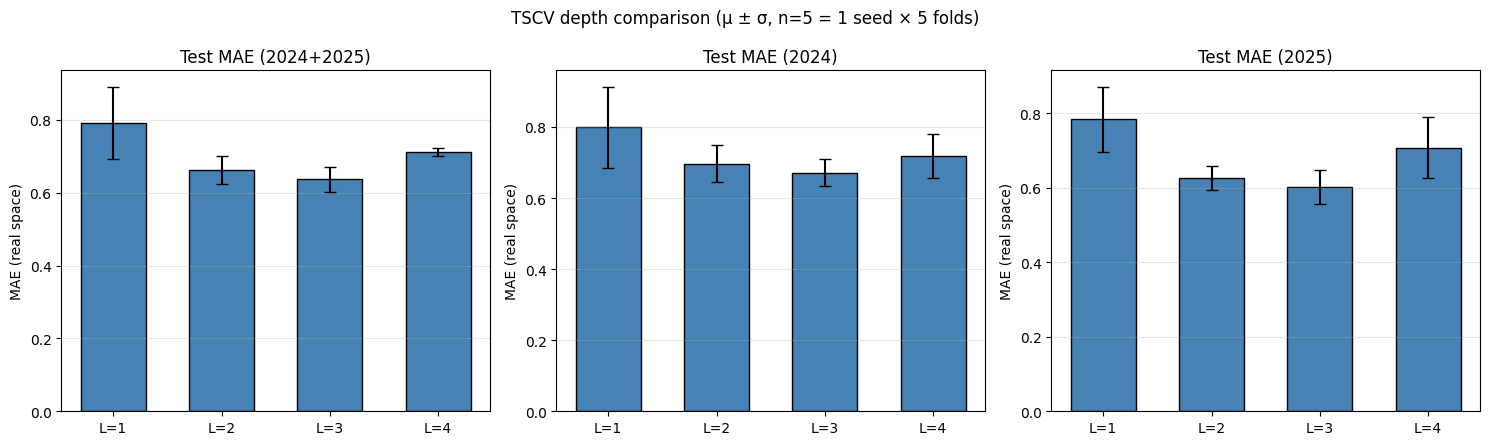

In [ ]:
rows = []
for (L, seed_offset, fold_idx), d in depth_tscv_runs.items():
    for t in PREDICTION_TARGETS + ['Overall']:
        rows.append({
            'depth': L, 'seed': d['seed'], 'fold': fold_idx, 'val_year': d['val_year'],
            'target': t,
            'val_mae': d['final_val_mae'] if t == 'Overall' else None,  # per-target val not stored
            'test_mae': d['test_res'].get(t),
            'test_2024_mae': d['test_res_2024'].get(t),
            'test_2025_mae': d['test_res_2025'].get(t),
            'best_val_mae': d['best_val_mae'],
            'best_val_epoch': d['best_val_epoch'],
        })
df_tscv_per_run = pd.DataFrame(rows)

summary_rows = []
for L in [1, 2, 3, 4]:
    sub_L = df_tscv_per_run[df_tscv_per_run['depth'] == L]
    val_per_run = pd.DataFrame([
        {'depth': L, 'seed_offset': so, 'fold_idx': fi, 'best_val_mae': depth_tscv_runs[(L, so, fi)]['best_val_mae']}
        for so in range(N_RUNS_TSCV) for fi in range(1, N_SPLITS + 1)
    ])
    avg_val_mae = float(val_per_run['best_val_mae'].mean())
    std_val_mae = float(val_per_run['best_val_mae'].std())
    for t in PREDICTION_TARGETS + ['Overall']:
        sub = sub_L[sub_L['target'] == t]
        summary_rows.append({
            'depth': L, 'target': t,
            'avg_val_mae': avg_val_mae if t == 'Overall' else None,
            'std_val_mae': std_val_mae if t == 'Overall' else None,
            'test_mae_mean': float(sub['test_mae'].mean()),
            'test_mae_std':  float(sub['test_mae'].std()),
            'test_2024_mean': float(sub['test_2024_mae'].mean()),
            'test_2024_std':  float(sub['test_2024_mae'].std()),
            'test_2025_mean': float(sub['test_2025_mae'].mean()),
            'test_2025_std':  float(sub['test_2025_mae'].std()),
        })
df_tscv_depth = pd.DataFrame(summary_rows)
display(df_tscv_depth.round(4))

val_by_depth = df_tscv_depth[df_tscv_depth['target'] == 'Overall'].set_index('depth')['avg_val_mae']
test_by_depth = df_tscv_depth[df_tscv_depth['target'] == 'Overall'].set_index('depth')['test_mae_mean']
test24_by_depth = df_tscv_depth[df_tscv_depth['target'] == 'Overall'].set_index('depth')['test_2024_mean']
test25_by_depth = df_tscv_depth[df_tscv_depth['target'] == 'Overall'].set_index('depth')['test_2025_mean']
print("\n=== Verdict (TSCV, depth only) ===")
for metric_name, series in [('Selection (avg val MAE)', val_by_depth),
                              ('Test MAE (all)', test_by_depth),
                              ('Test MAE (2024)', test24_by_depth),
                              ('Test MAE (2025)', test25_by_depth)]:
    best_L = series.idxmin()
    print(f"  {metric_name:30s}: best L={best_L} ({series[best_L]:.4f})")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
xs = np.arange(4)
width = 0.6
for i, (col, title) in enumerate([('test_mae_mean', 'Test MAE (2024+2025)'),
                                   ('test_2024_mean', 'Test MAE (2024)'),
                                   ('test_2025_mean', 'Test MAE (2025)')]):
    means = [df_tscv_depth[(df_tscv_depth['depth'] == L) & (df_tscv_depth['target'] == 'Overall')][col].iloc[0] for L in [1,2,3,4]]
    stds  = [df_tscv_depth[(df_tscv_depth['depth'] == L) & (df_tscv_depth['target'] == 'Overall')][col.replace('mean','std')].iloc[0] for L in [1,2,3,4]]
    ax[i].bar(xs, means, width, yerr=stds, capsize=4, color='steelblue', edgecolor='black')
    ax[i].set_xticks(xs); ax[i].set_xticklabels([f'L={L}' for L in [1,2,3,4]])
    ax[i].set_title(title); ax[i].set_ylabel('MAE (real space)'); ax[i].grid(True, alpha=0.3, axis='y')
fig.suptitle("TSCV depth comparison")
plt.tight_layout()
plt.show()


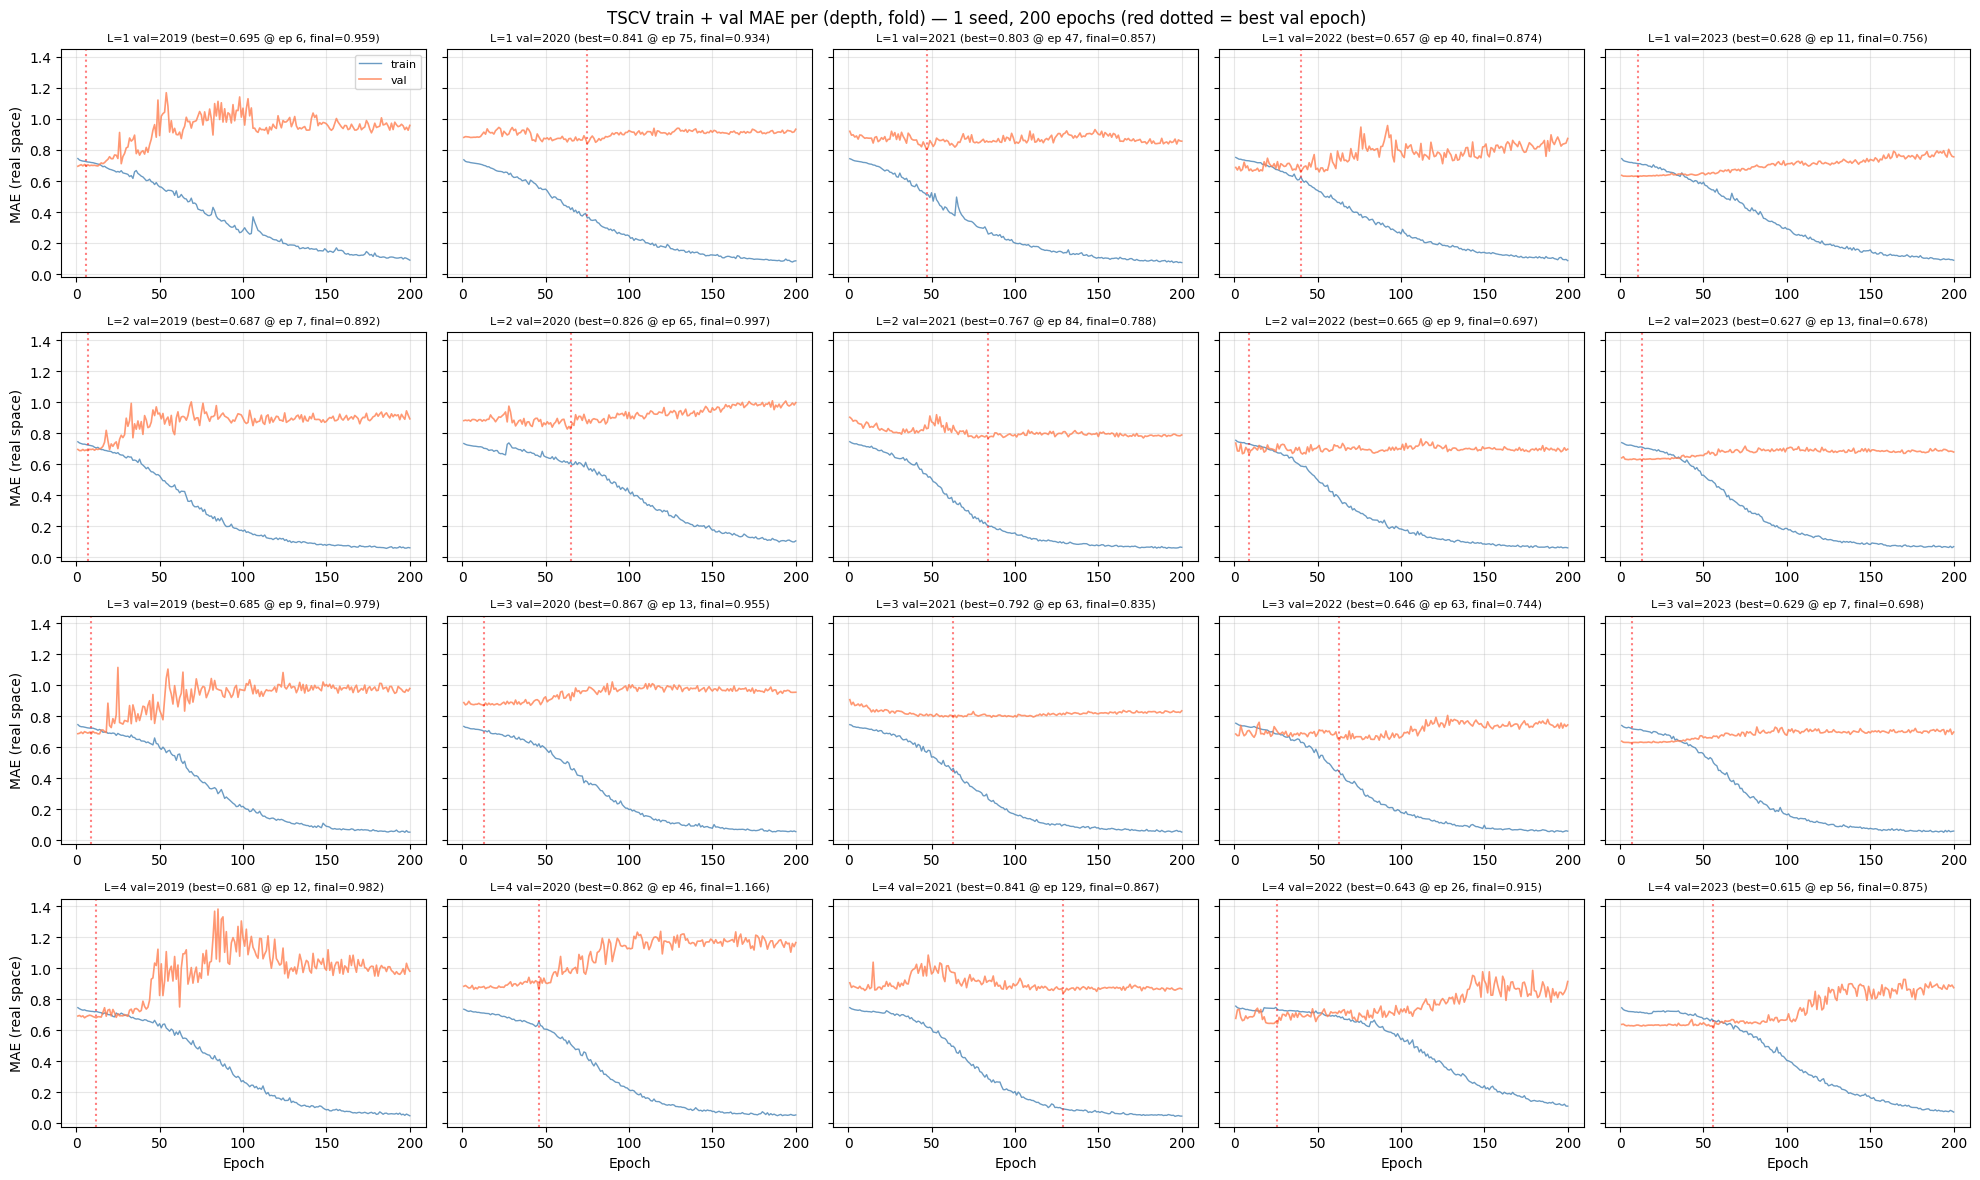

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(20, 12), sharey=True)
DEPTHS = [1, 2, 3, 4]
FOLD_VAL_YEARS = [2019, 2020, 2021, 2022, 2023]
for i, L in enumerate(DEPTHS):
    for j, fold_idx in enumerate([1, 2, 3, 4, 5]):
        ax = axes[i, j]
        for so in range(N_RUNS_TSCV):
            d = depth_tscv_runs.get((L, so, fold_idx))
            if d is None:
                continue
            epochs = range(1, len(d['val_mae_curve']) + 1)
            ax.plot(epochs, d['train_mae_curve'], color='steelblue', linewidth=1.0,
                    alpha=0.8, label='train' if (i == 0 and j == 0 and so == 0) else None)
            ax.plot(epochs, d['val_mae_curve'],   color='coral',    linewidth=1.2,
                    alpha=0.8, label='val'   if (i == 0 and j == 0 and so == 0) else None)
            ax.axvline(d['best_val_epoch'], color='red', linestyle=':', alpha=0.5)
        ax.set_title(f"L={L} val={FOLD_VAL_YEARS[j]} "
                     f"(best={d['best_val_mae']:.3f} @ ep {d['best_val_epoch']}, final={d['final_val_mae']:.3f})",
                     fontsize=8)
        if j == 0:
            ax.set_ylabel("MAE (real space)")
        if i == 3:
            ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()


## 2. Regularization Grid at L = 4

| Config | Dropout | Weight decay |
|--------|--------:|-------------:|
| no reg | 0.0 | 0.0 |
| dropout only | 0.2 | 0.0 |
| wd only | 0.0 | 1e-4 |
| dropout + wd | 0.2 | 1e-4 |

In [ ]:
REG_GRID = [
    {'label': 'no_reg',          'dropout': 0.0, 'weight_decay': 0.0},
    {'label': 'dropout_0.2',     'dropout': 0.2, 'weight_decay': 0.0},
    {'label': 'wd_1e-4',         'dropout': 0.0, 'weight_decay': 1e-4},
    {'label': 'drop0.2_wd1e-4',  'dropout': 0.2, 'weight_decay': 1e-4},
]
REG_DEPTH = 4
REG_EPOCHS = 100
reg_runs = {}

for cfg in REG_GRID:
    cfg_label = cfg['label']
    for seed_offset in range(N_RUNS_TSCV):
        seed = SEED + seed_offset
        for train_df, val_df, val_year, fold_idx in tscv_folds:
            set_seed(seed)
            model, train_loader, val_loader, test_loader, temp_sc, stat_sc = build_loaders_for_fold(
                params=CONFIG, num_layers=REG_DEPTH,
                train_raw_df=train_df, val_raw_df=val_df, test_raw_df=tscv_heldout_test_df,
                model_class=StackedLSTM, dropout=cfg['dropout'],
            )
            init_model_weights(model)
            opt = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=cfg['weight_decay'])

            criterion = nn.L1Loss(reduction='none')
            val_mae_curve  = []
            test_mae_curve = []
            best_val_mae = float('inf')
            best_val_epoch = -1
            best_test_at_best_val_mae = None

            for epoch in range(1, REG_EPOCHS + 1):
                model.train()
                for bx, by, bmask, bstatic, lengths in train_loader:
                    bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                    opt.zero_grad(set_to_none=True)
                    logits = model(bx, lengths, bstatic)
                    loss_m = criterion(logits, by)
                    mask_f = bmask.to(loss_m.dtype)
                    loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
                    if loss.requires_grad:
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                        opt.step()
                val_mae  = evaluate_loader(model, val_loader)['Overall']
                test_mae = evaluate_loader(model, test_loader)['Overall']
                val_mae_curve.append(val_mae)
                test_mae_curve.append(test_mae)
                if val_mae < best_val_mae:
                    best_val_mae = val_mae
                    best_val_epoch = epoch
                    best_test_at_best_val_mae = test_mae

            d = {
                'config': cfg_label, 'depth': REG_DEPTH,
                'dropout': cfg['dropout'], 'weight_decay': cfg['weight_decay'],
                'seed': seed, 'seed_offset': seed_offset, 'fold_idx': fold_idx,
                'val_year': int(val_year),
                'best_val_mae': best_val_mae,
                'best_val_epoch': best_val_epoch,
                'test_at_best_val_mae': best_test_at_best_val_mae,
                'val_at_epoch_100_mae':  val_mae_curve[-1],
                'test_at_epoch_100_mae': test_mae_curve[-1],
                'val_mae_curve':  val_mae_curve,
                'test_mae_curve': test_mae_curve,
            }
            reg_runs[(cfg_label, seed_offset, fold_idx)] = d
            print(f"  [{cfg_label} seed={seed_offset} fold={fold_idx} val={val_year}] "
                  f"best_val_mae={best_val_mae:.4f} @ ep {best_val_epoch:2d},  "
                  f"test_at_best_val_mae={best_test_at_best_val_mae:.4f},  "
                  f"test_at_epoch_100_mae={test_mae_curve[-1]:.4f}")

  [no_reg seed=0 fold=1 val=2019] best_val_mae=0.6762 @ ep 18,  test_at_best_val_mae=0.5815,  test_at_epoch_100_mae=0.6525
  [no_reg seed=0 fold=2 val=2020] best_val_mae=0.8517 @ ep 22,  test_at_best_val_mae=0.5826,  test_at_epoch_100_mae=0.5800
  [no_reg seed=0 fold=3 val=2021] best_val_mae=0.8128 @ ep 97,  test_at_best_val_mae=0.8210,  test_at_epoch_100_mae=0.8003
  [no_reg seed=0 fold=4 val=2022] best_val_mae=0.6552 @ ep 73,  test_at_best_val_mae=0.5857,  test_at_epoch_100_mae=0.6184
  [no_reg seed=0 fold=5 val=2023] best_val_mae=0.6293 @ ep 18,  test_at_best_val_mae=0.5754,  test_at_epoch_100_mae=0.7492
  [dropout_0.2 seed=0 fold=1 val=2019] best_val_mae=0.6823 @ ep  7,  test_at_best_val_mae=0.5811,  test_at_epoch_100_mae=0.7646
  [dropout_0.2 seed=0 fold=2 val=2020] best_val_mae=0.8392 @ ep 89,  test_at_best_val_mae=0.6171,  test_at_epoch_100_mae=0.6000
  [dropout_0.2 seed=0 fold=3 val=2021] best_val_mae=0.7973 @ ep 94,  test_at_best_val_mae=0.6146,  test_at_epoch_100_mae=0.6287
 

=== TSCV Reg Grid (L=4, 5 folds × 5 seeds × 4 configs) ===
  Showing the BEST (across seed, fold) for each config, not the mean.
  Total trainings: 20 = 4 configs × 1 seeds × 5 folds



,config,best_seed,best_fold,best_val_year,best_val_mae,best_val_epoch,test_at_best_val_mae,test_at_epoch_100_mae
0,no_reg,42,5,2023,0.6293,18,0.5754,0.7492
1,dropout_0.2,42,5,2023,0.6265,29,0.5780,0.6429
2,wd_1e-4,42,5,2023,0.6281,29,0.5711,0.5927
3,drop0.2_wd1e-4,42,5,2023,0.6268,29,0.5721,0.5943



Overall best config (lowest test_at_best_val_mae): wd_1e-4
  test_at_best_val_mae = 0.5711
  best_val_mae = 0.6281 at epoch 29
  best (seed, fold) = (0, 5), val_year=2023

Reference points:
  Shallow LSTM (L=1) at best epoch (15):  test_2025 = 0.582
  TSCV Section B (OLD, epoch-100, mean): drop0.2_wd1e-4 test MAE = 0.6085
  Section B (NEW, best-epoch, best seed-fold): wd_1e-4 test_mae = 0.5711


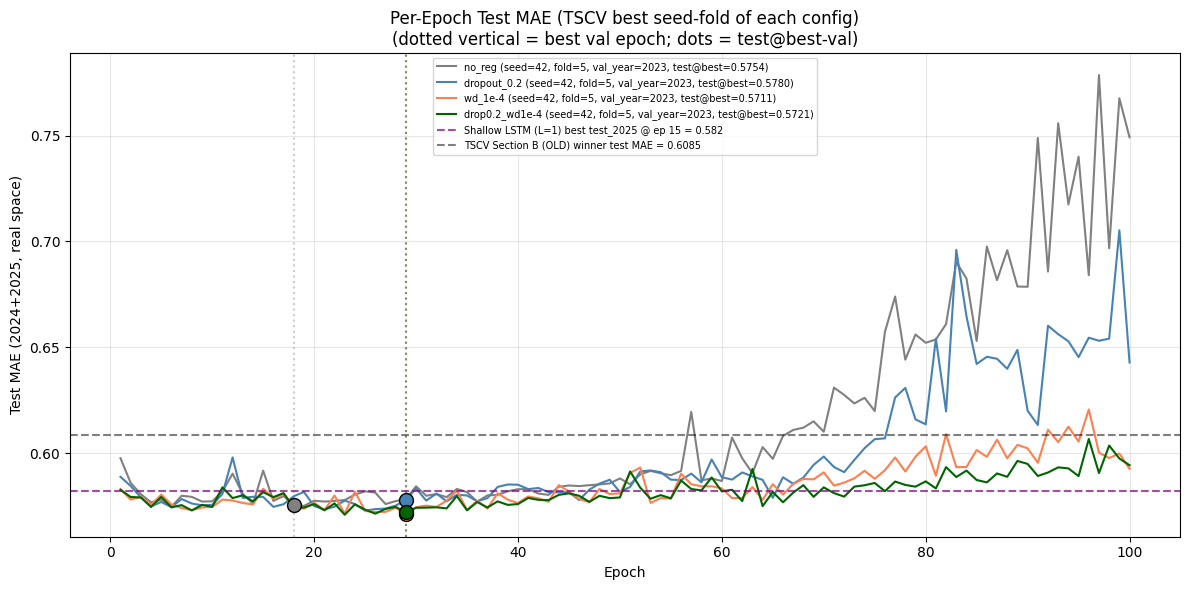

In [ ]:
best_per_config = {}
for cfg in REG_GRID:
    cfg_label = cfg['label']
    best_so, best_fi = min(
        ((so, fi) for so in range(N_RUNS_TSCV) for fi in range(1, N_SPLITS + 1)),
        key=lambda sf: reg_runs[(cfg_label, sf[0], sf[1])]['test_at_best_val_mae']
    )
    d = reg_runs[(cfg_label, best_so, best_fi)]
    best_per_config[cfg_label] = {
        'best_seed': d['seed'],
        'best_seed_offset': best_so,
        'best_fold': best_fi,
        'best_val_year': d['val_year'],
        'best_val_mae': d['best_val_mae'],
        'best_val_epoch': d['best_val_epoch'],
        'test_at_best_val_mae': d['test_at_best_val_mae'],
        'test_at_epoch_100_mae': d['test_at_epoch_100_mae'],
    }

rows = []
for cfg in REG_GRID:
    cfg_label = cfg['label']
    b = best_per_config[cfg_label]
    rows.append({
        'config': cfg_label,
        'best_seed': b['best_seed'],
        'best_fold': b['best_fold'],
        'best_val_year': b['best_val_year'],
        'best_val_mae': b['best_val_mae'],
        'best_val_epoch': b['best_val_epoch'],
        'test_at_best_val_mae': b['test_at_best_val_mae'],
        'test_at_epoch_100_mae': b['test_at_epoch_100_mae'],
    })
df_reg_best = pd.DataFrame(rows)

print("=== TSCV Reg Grid (L=4, 5 folds × 5 seeds × 4 configs) ===")
print("  Showing the BEST (across seed, fold) for each config, not the mean.")
print(f"  Total trainings: {len(REG_GRID) * N_RUNS_TSCV * N_SPLITS} = {len(REG_GRID)} configs × {N_RUNS_TSCV} seeds × {N_SPLITS} folds")
print()
display(df_reg_best.round(4))

# Overall best
overall_best_label = min(best_per_config, key=lambda k: best_per_config[k]['test_at_best_val_mae'])
overall_best = best_per_config[overall_best_label]
print(f"\nOverall best config (lowest test_at_best_val_mae): {overall_best_label}")
print(f"  test_at_best_val_mae = {overall_best['test_at_best_val_mae']:.4f}")
print(f"  best_val_mae = {overall_best['best_val_mae']:.4f} at epoch {overall_best['best_val_epoch']}")
print(f"  best (seed, fold) = ({overall_best['best_seed_offset']}, {overall_best['best_fold']}), val_year={overall_best['best_val_year']}")

# Reference comparison
shallow_lstm_best_test_2025 = 0.5820
tscv_old_winner_test_mae = 0.6085
print(f"\nReference points:")
print(f"  Shallow LSTM (L=1) at best epoch (15):  test_2025 = {shallow_lstm_best_test_2025}")
print(f"  TSCV Section B (OLD, epoch-100, mean): drop0.2_wd1e-4 test MAE = {tscv_old_winner_test_mae}")
print(f"  Section B (NEW, best-epoch, best seed-fold): {overall_best_label} test_mae = {overall_best['test_at_best_val_mae']:.4f}")

# Plot: per-epoch test_mae curves for the best (seed, fold) of each cfg
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = {'no_reg': 'gray', 'dropout_0.2': 'steelblue', 'wd_1e-4': 'coral', 'drop0.2_wd1e-4': 'darkgreen'}
for cfg in REG_GRID:
    cfg_label = cfg['label']
    b = best_per_config[cfg_label]
    d = reg_runs[(cfg_label, b['best_seed_offset'], b['best_fold'])]
    epochs = range(1, len(d['test_mae_curve']) + 1)
    ax.plot(epochs, d['test_mae_curve'], color=colors[cfg_label], linewidth=1.5,
            label=f"{cfg_label} (seed={b['best_seed']}, fold={b['best_fold']}, val_year={b['best_val_year']}, test@best={d['test_at_best_val_mae']:.4f})")
    ax.axvline(d['best_val_epoch'], color=colors[cfg_label], linestyle=':', alpha=0.4)
    ax.scatter([d['best_val_epoch']], [d['test_at_best_val_mae']],
               color=colors[cfg_label], s=100, zorder=5, edgecolors='black', linewidths=1)

ax.axhline(y=shallow_lstm_best_test_2025, color='purple', linestyle='--', alpha=0.7,
           label=f'Shallow LSTM (L=1) best test_2025 @ ep 15 = {shallow_lstm_best_test_2025}')
ax.axhline(y=tscv_old_winner_test_mae, color='black', linestyle='--', alpha=0.5,
           label=f'TSCV Section B (OLD) winner test MAE = {tscv_old_winner_test_mae}')

ax.set_xlabel("Epoch")
ax.set_ylabel("Test MAE (2024+2025, real space)")
ax.set_title("Per-Epoch Test MAE (TSCV best seed-fold of each config)\n"
             "(dotted vertical = best val epoch; dots = test@best-val)")
ax.legend(fontsize=7, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 2024 as Validation
- **Train:**  ≤ 2023
- **Validation:**  2024
- **Test:**  2025

In [ ]:
DEPLOY_REG_GRID = [
    {'label': 'no_reg',         'dropout': 0.0, 'weight_decay': 0.0},
    {'label': 'dropout_0.2',    'dropout': 0.2, 'weight_decay': 0.0},
    {'label': 'wd_1e-4',        'dropout': 0.0, 'weight_decay': 1e-4},
    {'label': 'drop0.2_wd1e-4', 'dropout': 0.2, 'weight_decay': 1e-4},
]
DEPLOY_DEPTH = 4
DEPLOY_EPOCHS = 100

deploy_train_df = data_df_imp[data_df_imp['year'] <= 2023].copy()
deploy_val_df   = data_df_imp[data_df_imp['year'] == 2024].copy()
deploy_test_df  = data_df_imp[data_df_imp['year'] == 2025].copy()

print("D. 2024-as-Validation Deployment Scenario — single fold")
print(f"  Train: years <= 2023  (N={len(deploy_train_df)})")
print(f"  Val:   2024           (N={len(deploy_val_df)})")
print(f"  Test:  2025           (N={len(deploy_test_df)})")
print(f"  Depth: L={DEPLOY_DEPTH},  Epochs: {DEPLOY_EPOCHS},  N_RUNS={N_RUNS_TSCV},  Configs: {len(DEPLOY_REG_GRID)}")
print(f"  Per-epoch val + test MAE evaluation enabled (matches cell 37 protocol).")
print(f"  best_val_mae = min MAE on 2024 across epochs; test_at_best_val_mae = test MAE on 2025 at that epoch.")


D. 2024-as-Validation Deployment Scenario — single fold
  Train: years <= 2023  (N=4826)
  Val:   2024           (N=469)
  Test:  2025           (N=450)
  Depth: L=4,  Epochs: 100,  N_RUNS=1,  Configs: 4


In [ ]:
deploy_runs = {}
for seed_offset in range(N_RUNS_TSCV):
    seed = SEED + seed_offset
    for cfg in DEPLOY_REG_GRID:
        cfg_label = cfg['label']
        set_seed(seed)
        model, train_loader, val_loader, test_loader, temp_sc, stat_sc = build_loaders_for_fold(
            params=CONFIG, num_layers=DEPLOY_DEPTH,
            train_raw_df=deploy_train_df, val_raw_df=deploy_val_df, test_raw_df=deploy_test_df,
            model_class=StackedLSTM, dropout=cfg['dropout'],
        )
        init_model_weights(model)
        opt = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'], weight_decay=cfg['weight_decay'])

        criterion = nn.L1Loss(reduction='none')
        val_mae_curve  = []
        test_mae_curve = []
        best_val_mae = float('inf')
        best_val_epoch = -1
        best_test_at_best_val_mae = None

        for epoch in range(1, DEPLOY_EPOCHS + 1):
            # Training step
            model.train()
            for bx, by, bmask, bstatic, lengths in train_loader:
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                opt.zero_grad(set_to_none=True)
                logits = model(bx, lengths, bstatic)
                loss_m = criterion(logits, by)
                mask_f = bmask.to(loss_m.dtype)
                loss = (loss_m * mask_f).sum() / mask_f.sum().clamp(min=1)
                if loss.requires_grad:
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                    opt.step()
            val_mae  = evaluate_loader(model, val_loader)['Overall']
            test_mae = evaluate_loader(model, test_loader)['Overall']
            val_mae_curve.append(val_mae)
            test_mae_curve.append(test_mae)
            if val_mae < best_val_mae:
                best_val_mae = val_mae
                best_val_epoch = epoch
                best_test_at_best_val_mae = test_mae

        d = {
            'config': cfg_label, 'depth': DEPLOY_DEPTH,
            'dropout': cfg['dropout'], 'weight_decay': cfg['weight_decay'],
            'seed': seed, 'seed_offset': seed_offset,
            'best_val_mae': best_val_mae,
            'best_val_epoch': best_val_epoch,
            'test_at_best_val_mae': best_test_at_best_val_mae,
            'val_at_epoch_100_mae':  val_mae_curve[-1],
            'test_at_epoch_100_mae': test_mae_curve[-1],
            'val_mae_curve':  val_mae_curve,
            'test_mae_curve': test_mae_curve,
        }
        deploy_runs[(cfg_label, seed_offset)] = d
        print(f"  [{cfg_label} seed={seed_offset}] "
              f"best_val_mae={best_val_mae:.4f} @ ep {best_val_epoch:2d},  "
              f"test_at_best_val_mae={best_test_at_best_val_mae:.4f},  "
              f"test_at_epoch_100_mae={test_mae_curve[-1]:.4f}")

  [no_reg seed=0] val_2024_overall=0.7399  test_2025_overall=0.6732  (best_val=0.5863 @ ep 16)
  [dropout_0.2 seed=0] val_2024_overall=0.5939  test_2025_overall=0.5552  (best_val=0.5836 @ ep 21)
  [wd_1e-4 seed=0] val_2024_overall=0.7841  test_2025_overall=0.9153  (best_val=0.5697 @ ep 42)
  [drop0.2_wd1e-4 seed=0] val_2024_overall=0.6667  test_2025_overall=0.6182  (best_val=0.5835 @ ep 25)
  [no_reg seed=1] val_2024_overall=0.9022  test_2025_overall=1.8165  (best_val=0.5817 @ ep 17)
  [dropout_0.2 seed=1] val_2024_overall=0.7207  test_2025_overall=1.3312  (best_val=0.5801 @ ep 18)
  [wd_1e-4 seed=1] val_2024_overall=0.6178  test_2025_overall=0.6715  (best_val=0.5822 @ ep 23)
  [drop0.2_wd1e-4 seed=1] val_2024_overall=0.6441  test_2025_overall=0.7450  (best_val=0.5812 @ ep 26)
  [no_reg seed=2] val_2024_overall=0.7763  test_2025_overall=0.9016  (best_val=0.5734 @ ep 34)
  [dropout_0.2 seed=2] val_2024_overall=0.8568  test_2025_overall=1.4945  (best_val=0.5892 @ ep 11)
  [wd_1e-4 seed=2


=== 2024-as-Val Deployment Scenario (L=4, train ≤ 2023, val = 2024, test = 2025) ===
  n = 1 seed per config


,config,dropout,weight_decay,val_2024_mae,test_2025_mae,best_val_mae,best_val_epoch
0,no_reg,0.0,0.0000,0.7967,0.9768,0.5801,22
1,dropout_0.2,0.2,0.0000,0.7533,0.9492,0.5827,20
2,wd_1e-4,0.0,0.0001,0.6847,0.8970,0.5784,25
3,drop0.2_wd1e-4,0.2,0.0001,0.7337,0.7106,0.5821,23



  2024-val-winner (lowest val_2024_mae): wd_1e-4  (val_2024=0.6847,  test_2025=0.8970)
  2025-test-winner (lowest test_2025_mae): drop0.2_wd1e-4  (val_2024=0.7337,  test_2025=0.7106)


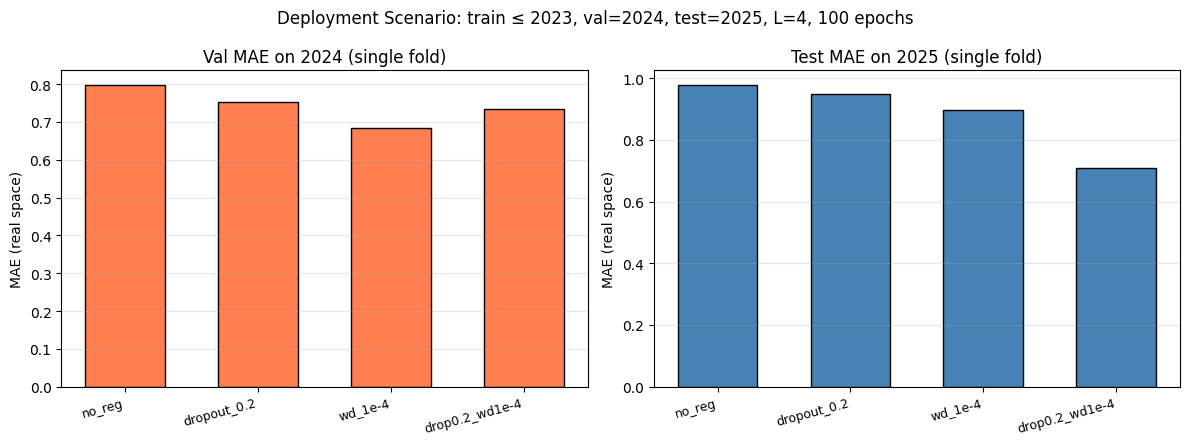

In [ ]:
best_per_config = {}
for cfg in DEPLOY_REG_GRID:
    cfg_label = cfg['label']
    best_so = min(range(N_RUNS_TSCV),
                  key=lambda so: deploy_runs[(cfg_label, so)]['test_at_best_val_mae'])
    best_per_config[cfg_label] = {
        'best_seed': best_so,
        'best_seed_value': deploy_runs[(cfg_label, best_so)]['seed'],
        'best_test_at_best_val_mae': deploy_runs[(cfg_label, best_so)]['test_at_best_val_mae'],
        'best_val_mae':  deploy_runs[(cfg_label, best_so)]['best_val_mae'],
        'best_val_epoch': deploy_runs[(cfg_label, best_so)]['best_val_epoch'],
        'test_at_epoch_100_mae': deploy_runs[(cfg_label, best_so)]['test_at_epoch_100_mae'],
    }

rows = []
for cfg in DEPLOY_REG_GRID:
    cfg_label = cfg['label']
    b = best_per_config[cfg_label]
    rows.append({
        'config': cfg_label,
        'best_seed': b['best_seed_value'],
        'best_val_mae': b['best_val_mae'],
        'best_val_epoch': b['best_val_epoch'],
        'test_at_best_val_mae': b['best_test_at_best_val_mae'],
        'test_at_epoch_100_mae': b['test_at_epoch_100_mae'],
    })
df_best = pd.DataFrame(rows)

print("=== 2024-as-Val Deployment Scenario (L=4, train <= 2023, val = 2024, test = 2025) ===")
print("  Showing the BEST (across seeds) result for each config, not the mean.")
print(f"  Total trainings: {len(DEPLOY_REG_GRID) * N_RUNS_TSCV} = {len(DEPLOY_REG_GRID)} configs x {N_RUNS_TSCV} seeds.")
print()
display(df_best.round(4))

# Overall best config (lowest test_at_best_val_mae)
overall_best_label = min(best_per_config, key=lambda k: best_per_config[k]['best_test_at_best_val_mae'])
overall_best = best_per_config[overall_best_label]
print(f"\nOverall best config (lowest test_at_best_val_mae): {overall_best_label}")
print(f"  test_at_best_val_mae = {overall_best['best_test_at_best_val_mae']:.4f}")
print(f"  best_val_mae = {overall_best['best_val_mae']:.4f} at epoch {overall_best['best_val_epoch']}")
print(f"  best seed = {overall_best['best_seed_value']}")

# Reference comparison
tscv_winner_label = 'drop0.2_wd1e-4'
tscv_winner_test_mae = 0.6085
shallow_lstm_best_test_2025 = 0.5820
print(f"\nReference points:")
print(f"  Shallow LSTM (L=1) at best epoch (15):  test_2025 = {shallow_lstm_best_test_2025}")
print(f"  TSCV Section B winner ({tscv_winner_label}): test MAE = {tscv_winner_test_mae}")
print(f"  Section D best ({overall_best_label}):            test_2025 = {overall_best['best_test_at_best_val_mae']:.4f}")

# Plot: per-epoch test_2025 curves for the BEST seed of each config
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
colors = {'no_reg': 'gray', 'dropout_0.2': 'steelblue', 'wd_1e-4': 'coral', 'drop0.2_wd1e-4': 'darkgreen'}
for cfg in DEPLOY_REG_GRID:
    cfg_label = cfg['label']
    best_so = best_per_config[cfg_label]['best_seed']
    d = deploy_runs[(cfg_label, best_so)]
    epochs = range(1, len(d['test_mae_curve']) + 1)
    ax.plot(epochs, d['test_mae_curve'], color=colors[cfg_label], linewidth=1.5,
            label=f"{cfg_label} (seed={best_so}, test@best_val={d['test_at_best_val_mae']:.4f})")
    ax.axvline(d['best_val_epoch'], color=colors[cfg_label], linestyle=':', alpha=0.4)
    ax.scatter([d['best_val_epoch']], [d['test_at_best_val_mae']],
               color=colors[cfg_label], s=100, zorder=5, edgecolors='black', linewidths=1)

ax.axhline(y=shallow_lstm_best_test_2025, color='purple', linestyle='--', alpha=0.7,
           label=f'Shallow LSTM (L=1) best test_2025 @ ep 15 = {shallow_lstm_best_test_2025}')
ax.axhline(y=tscv_winner_test_mae, color='black', linestyle='--', alpha=0.5,
           label=f'TSCV Section B winner test MAE = {tscv_winner_test_mae}')

ax.set_xlabel("Epoch")
ax.set_ylabel("Test MAE on 2025 (real space)")
ax.set_title("Per-Epoch Test MAE on 2025 (best seed of each config)\n"
             "(dotted vertical = best val epoch; dots = test@best-val)")
ax.legend(fontsize=8, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 2025 as Validation

- **Train:**  ≤ 2022
- **Validation:**  2025 (in the future)
- **Test:** 2023 and 2024

In [ ]:
FV_DEPTHS = [1, 2, 3, 4]
N_SEEDS_FV = 5
FV_CONFIG = {
    "hidden_size": 128,
    "batch_size": 32,
    "lr": 1e-3,
    "dropout": 0.0,
    "weight_decay": 0.0,
}

fv_depth_results = []
fv_depth_histories = {}

for nl in FV_DEPTHS:
    for seed in range(N_SEEDS_FV):
        set_seed(SEED + seed)
        model, train_loader, val_loader, test23_loader, test24_loader, test_combined_loader = build_loaders_fv(FV_CONFIG, nl)
        init_model_weights(model, head_std=1e-3)
        optimizer = torch.optim.Adam(model.parameters(), lr=FV_CONFIG["lr"], weight_decay=FV_CONFIG["weight_decay"])
        model, history = train_with_diagnostics(
            model, train_loader, val_loader, optimizer,
            grad_clip=5.0, use_scheduler=False, max_epochs=MAX_EPOCHS, verbose=False,
        )
        fv_depth_histories[(nl, seed)] = history
        val_mae = eval_mae_per_target(model, val_loader)
        test23_mae = eval_mae_per_target(model, test23_loader)
        test24_mae = eval_mae_per_target(model, test24_loader)
        test_combined_mae = eval_mae_per_target(model, test_combined_loader)
        for tgt in PREDICTION_TARGETS + ["Overall"]:
            fv_depth_results.append({
                "num_layers": nl, "seed": seed, "target": tgt,
                "val_2025_mae": val_mae.get(tgt),
                "test_2023_mae": test23_mae.get(tgt),
                "test_2024_mae": test24_mae.get(tgt),
                "test_combined_mae": test_combined_mae.get(tgt),
                "best_val_mae": min(history["val_mae"]),
                "final_train_mae": history["train_mae"][-1],
            })
        print(f"[layers={nl} seed={seed}] val_2025={val_mae['Overall']:.4f} "
              f"test_2023={test23_mae['Overall']:.4f} test_2024={test24_mae['Overall']:.4f} "
              f"test_combined={test_combined_mae['Overall']:.4f} "
              f"best_val_mae={min(history['val_mae']):.4f}")

df_fv_runs = pd.DataFrame(fv_depth_results)

def fv_agg_mean_std(grp):
    metrics = ["val_2025_mae", "test_2023_mae", "test_2024_mae", "test_combined_mae", "best_val_mae", "final_train_mae"]
    out = [int(len(grp))]
    for m in metrics:
        out.append(float(grp[m].mean()))
        out.append(float(grp[m].std()))
    return out

result = df_fv_runs.groupby(["num_layers", "target"]).apply(fv_agg_mean_std)
df_fv_summary = pd.DataFrame(result.tolist(), index=result.index).reset_index()
df_fv_summary.columns = [
    "num_layers", "target", "n_seeds",
    "val_2025_mae_mean", "val_2025_mae_std",
    "test_2023_mae_mean", "test_2023_mae_std",
    "test_2024_mae_mean", "test_2024_mae_std",
    "test_combined_mae_mean", "test_combined_mae_std",
    "best_val_mae_mean", "best_val_mae_std",
    "final_train_mae_mean", "final_train_mae_std",
]

print("\n=== Depth sweep (1, 2, 3, 4 layers) — Train <= 2022, Val = 2025, Test = 2023 & 2024 ===")
display(df_fv_summary.round(4))

[layers=1 seed=0] val_2025=0.7873 test_2023=0.9910 test_2024=0.8644 test_combined=0.9270 best_val_mae=0.5587
[layers=1 seed=1] val_2025=0.7576 test_2023=0.7550 test_2024=0.7281 test_combined=0.7414 best_val_mae=0.5612
[layers=1 seed=2] val_2025=0.6124 test_2023=0.7201 test_2024=0.6798 test_combined=0.6998 best_val_mae=0.5541
[layers=1 seed=3] val_2025=0.6730 test_2023=0.7258 test_2024=0.7253 test_combined=0.7256 best_val_mae=0.5580
[layers=1 seed=4] val_2025=0.6812 test_2023=0.8830 test_2024=0.8969 test_combined=0.8900 best_val_mae=0.5574
[layers=2 seed=0] val_2025=0.7003 test_2023=0.6994 test_2024=0.7016 test_combined=0.7005 best_val_mae=0.5531
[layers=2 seed=1] val_2025=0.6411 test_2023=0.6492 test_2024=0.7522 test_combined=0.7013 best_val_mae=0.5552
[layers=2 seed=2] val_2025=0.6482 test_2023=0.6628 test_2024=0.7151 test_combined=0.6892 best_val_mae=0.5536
[layers=2 seed=3] val_2025=0.6097 test_2023=0.7090 test_2024=0.6879 test_combined=0.6983 best_val_mae=0.5514
[layers=2 seed=4] v

/tmp/ipykernel_543/3703520343.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df_fv_runs.groupby(["num_layers", "target"]).apply(fv_agg_mean_std)


,num_layers,target,n_seeds,val_2025_mae_mean,val_2025_mae_std,test_2023_mae_mean,test_2023_mae_std,test_2024_mae_mean,test_2024_mae_std,test_combined_mae_mean,test_combined_mae_std,best_val_mae_mean,best_val_mae_std,final_train_mae_mean,final_train_mae_std
0,1,EBITDA,5,0.5901,0.2007,0.7389,0.3971,0.7286,0.2060,0.7337,0.2989,0.5579,0.0026,0.1038,0.0093
1,1,Net_Income,5,0.7628,0.0710,0.8633,0.1167,0.8292,0.1441,0.8460,0.1289,0.5579,0.0026,0.1038,0.0093
2,1,Overall,5,0.7023,0.0701,0.8150,0.1185,0.7789,0.0955,0.7968,0.1039,0.5579,0.0026,0.1038,0.0093
3,1,ROA,5,0.7540,0.0935,0.8428,0.0515,0.7785,0.0714,0.8104,0.0521,0.5579,0.0026,0.1038,0.0093
4,2,EBITDA,5,0.4669,0.0537,0.4851,0.0340,0.5589,0.0480,0.5223,0.0314,0.5536,0.0015,0.0708,0.0070
5,2,Net_Income,5,0.7707,0.0629,0.7766,0.0208,0.8248,0.0650,0.8010,0.0261,0.5536,0.0015,0.0708,0.0070
6,2,Overall,5,0.6500,0.0326,0.6765,0.0261,0.7257,0.0352,0.7014,0.0102,0.5536,0.0015,0.0708,0.0070
7,2,ROA,5,0.7123,0.0301,0.7677,0.0286,0.7929,0.0587,0.7804,0.0228,0.5536,0.0015,0.0708,0.0070
8,3,EBITDA,5,0.4736,0.0741,0.5121,0.0492,0.5216,0.0356,0.5169,0.0361,0.5536,0.0008,0.0548,0.0014
9,3,Net_Income,5,0.7988,0.0895,0.8186,0.0501,0.8030,0.0462,0.8107,0.0465,0.5536,0.0008,0.0548,0.0014


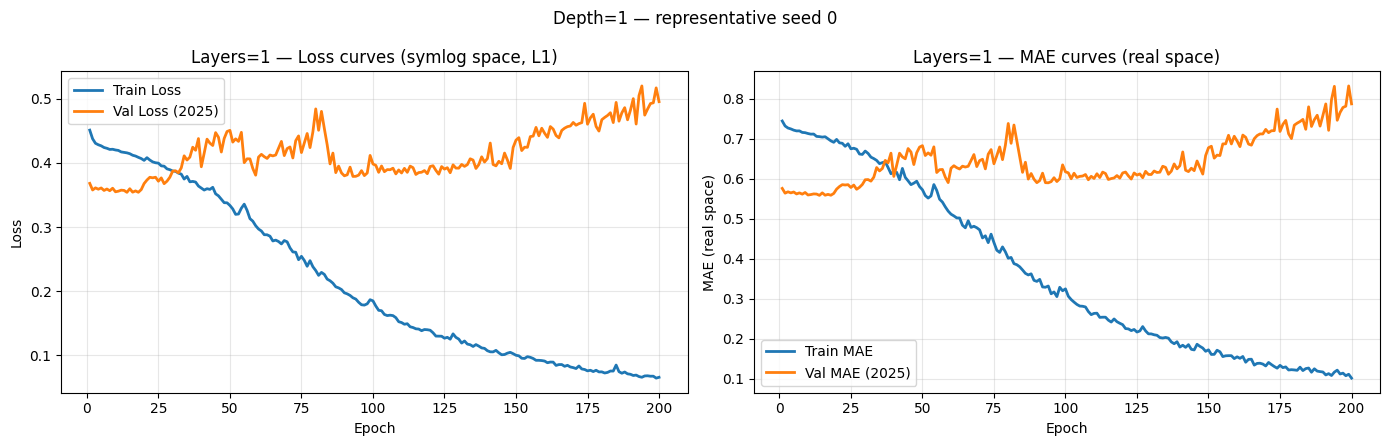

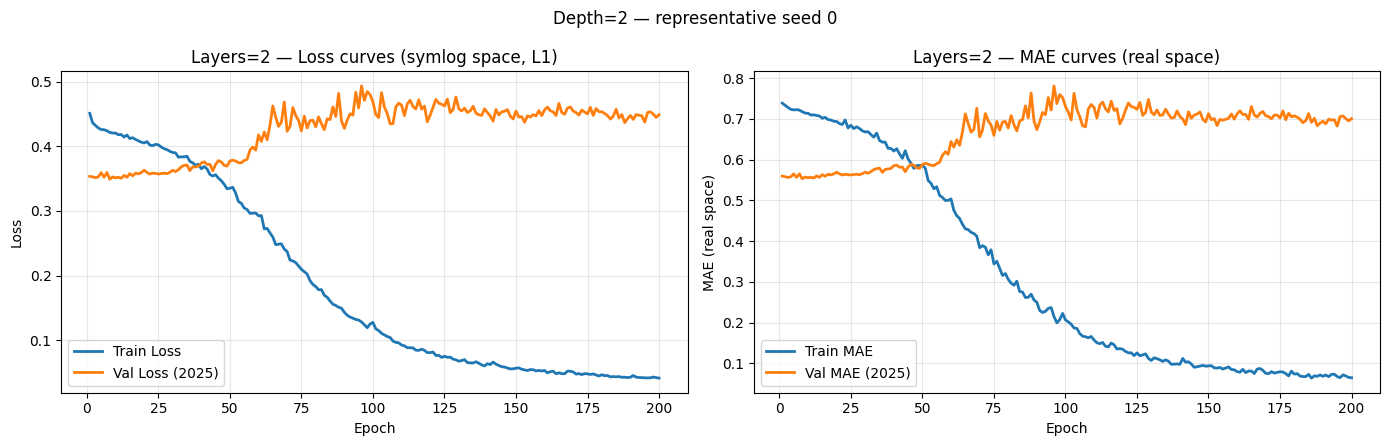

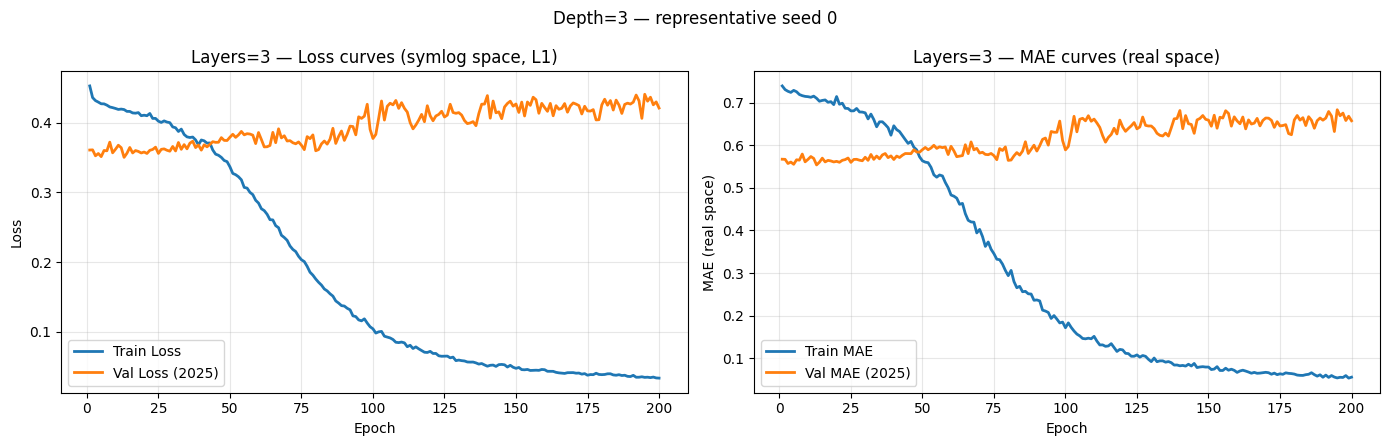

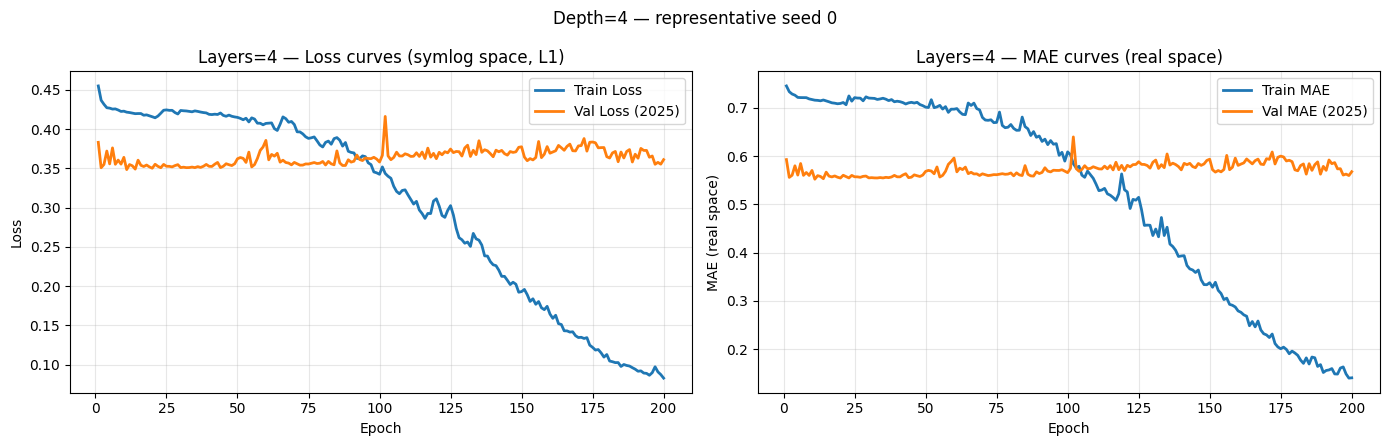

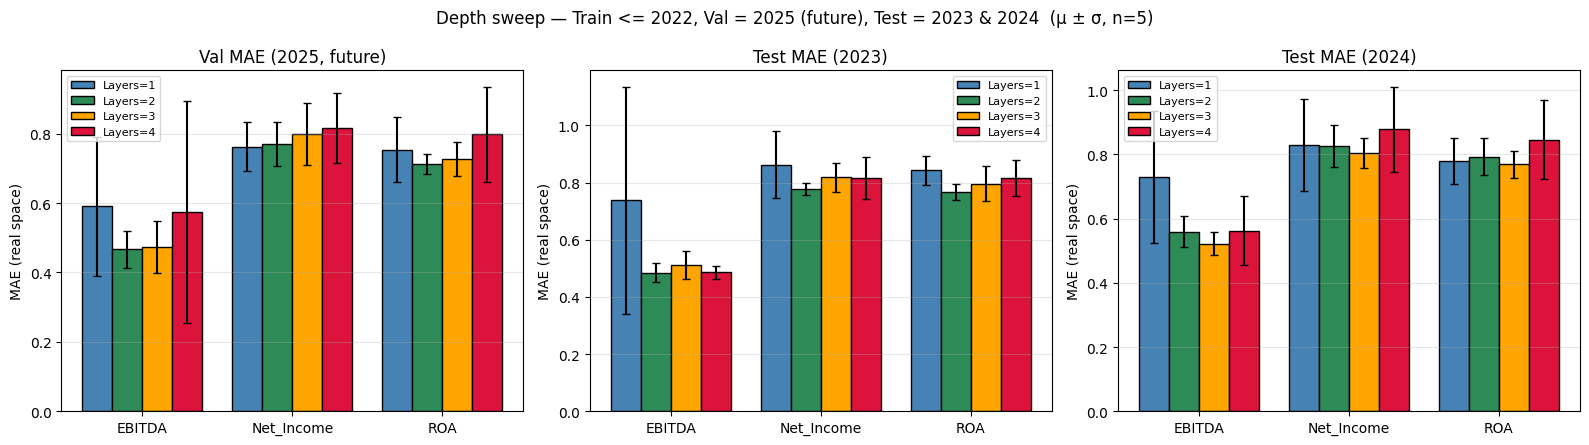

In [ ]:
for nl in FV_DEPTHS:
    history = fv_depth_histories[(nl, 0)]
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].plot(epochs, history["train_loss"], label="Train Loss", linewidth=2)
    axes[0].plot(epochs, history["val_loss"], label="Val Loss (2025)", linewidth=2)
    axes[0].set_title(f"Layers={nl} — Loss curves (symlog space, L1)")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history["train_mae"], label="Train MAE", linewidth=2)
    axes[1].plot(epochs, history["val_mae"], label="Val MAE (2025)", linewidth=2)
    axes[1].set_title(f"Layers={nl} — MAE curves (real space)")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (real space)")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    fig.suptitle(f"Depth={nl} — representative seed 0")
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
metric_titles = [
    ("val_2025_mae", "Val MAE (2025, future)"),
    ("test_2023_mae", "Test MAE (2023)"),
    ("test_2024_mae", "Test MAE (2024)"),
]
x = np.arange(len(PREDICTION_TARGETS))
width = 0.2
colors = ["steelblue", "seagreen", "orange", "crimson"]
for ax_i, (metric, title) in zip(ax, metric_titles):
    for j, nl in enumerate(FV_DEPTHS):
        sub = df_fv_runs[(df_fv_runs["num_layers"] == nl) & (df_fv_runs["target"].isin(PREDICTION_TARGETS))]
        means = sub.groupby("target")[metric].mean().reindex(PREDICTION_TARGETS).values
        stds = sub.groupby("target")[metric].std().reindex(PREDICTION_TARGETS).fillna(0).values
        ax_i.bar(x + (j - len(FV_DEPTHS)/2 + 0.5) * width, means, width,
                 yerr=stds, capsize=3,
                 label=f"Layers={nl}", color=colors[j], edgecolor="black")
    ax_i.set_xticks(x); ax_i.set_xticklabels(PREDICTION_TARGETS)
    ax_i.set_title(title); ax_i.set_ylabel("MAE (real space)")
    ax_i.legend(fontsize=8); ax_i.grid(True, alpha=0.3, axis='y')
fig.suptitle(f"Depth sweep — Train <= 2022, Val = 2025 (future), Test = 2023 & 2024  (μ ± σ, n={N_SEEDS_FV})")
plt.tight_layout()
plt.show()